In [2]:
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from binary_encoder import BinaryEncoder
from prepare_data import prepare

# Prepare data

In [ ]:
(x_train, y_train), df_train = prepare("../data/treino.csv")


In [4]:
x_train.shape, y_train.shape

((144194, 36), (144194,))

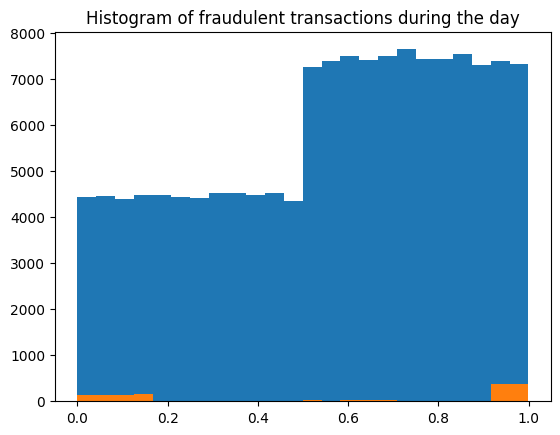

In [5]:
plt.hist(df_train[df_train["is_fraud"] == 0]["trans_time"], bins=24)
plt.hist(df_train[df_train["is_fraud"] == 1]["trans_time"], bins=24)
plt.title("Histogram of fraudulent transactions during the day")
plt.show()

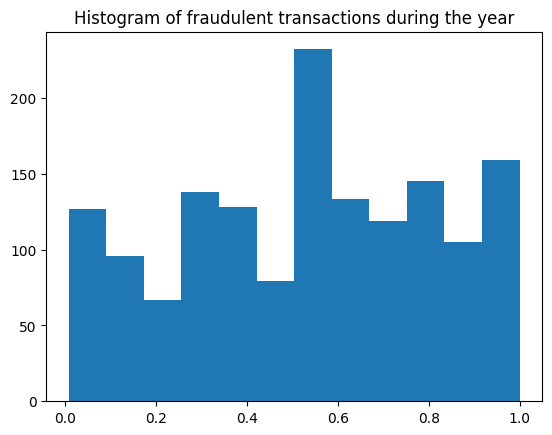

In [6]:
plt.hist(df_train[df_train["is_fraud"] == 1]["trans_date"], bins=12)
plt.title("Histogram of fraudulent transactions during the year")
plt.show()



# Model

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import Sequential

In [10]:
model = Sequential([
        Dense(128, activation="relu", input_shape=(36,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(1, activation="sigmoid")
    ])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ]
)

/home/matheus/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    x_train, y_train,
    validation_split = 0.2,
    epochs=10,
    batch_size=256
)

Epoch 1/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9156 - auc: 0.5094 - loss: 0.2358 - precision: 0.0111 - recall: 0.0804 - val_accuracy: 0.9889 - val_auc: 0.6287 - val_loss: 0.0599 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9894 - auc: 0.5829 - loss: 0.0628 - precision: 0.0625 - recall: 8.2850e-04 - val_accuracy: 0.9889 - val_auc: 0.6855 - val_loss: 0.0588 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9894 - auc: 0.6634 - loss: 0.0580 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9889 - val_auc: 0.7468 - val_loss: 0.0559 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
451/451 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9895 - auc: 0.7116 - loss: 0.0554 - precision: 0.3529 - recall: 0.0050 - val_accuracy: 0.9889 - val_auc: 0.7804 - val_loss: 0.0533 - val_precision: 0.0000e+00 - val_recal

In [14]:
evaluation = model.evaluate(x_test, y_test)

NameError: name 'x_test' is not defined